<p style="padding:5px;background-color: #007f99 ;border:1px solid black;border-radius:20px;font-weight:bold;font-size:2em;padding:15px;text-align:center;"> 
   Trie et autocomplétion
    <br>

</p>

Dans ce TP, on va étudier un type d'arbre (appelé "trie" ou "arbre préfixe") servant à stocker une collection de mots.

Dans le trie, on associe à chaque arrête une lettre, et à chaque noeud un booléen pour signaler si on est à la fin d'un mot ou non. 

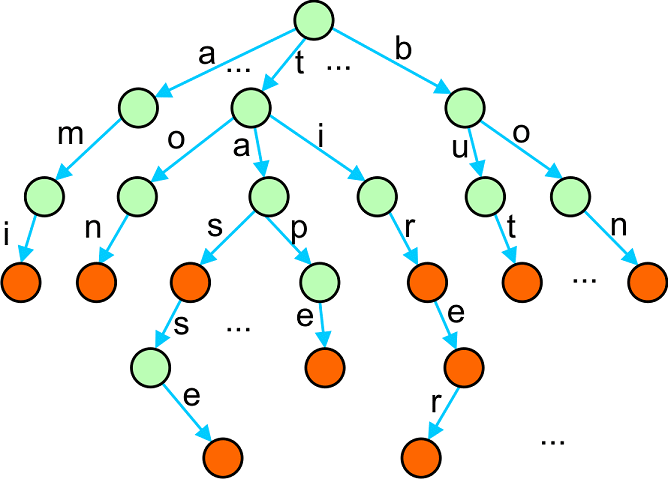

Dans l'exemple ci-dessus, le trie représente les mots "ami", "ton", "tas", "tasse", "tape", "tir", "tire", "tirer", "but" et "bon". Ce sont tous les chemins de la racine à un noeud orange. 

En revanche, les mots "am" ou "tass" ne sont pas des mots, car le chemin pour y arriver termine sur un noeud vert. 

# Représentation en OCaml

On va utiliser un type d'arbre général, avec 
- pour le type de donnée stocké dans les noeuds, un booléen (`bool`)
- dans chaque arrête, on ajoute un caractère (`char`)

On va supposer que le trie ne peux jamais être vide. 

In [1]:
type trie = 
    |N of bool * (char * trie) list;;

type trie = N of bool * (char * trie) list

Par exemple, on peut représenter un trie stockant les mots "ta", "tu", et "tas". 

In [2]:
let ex_1 : trie = 
    N (false, [
        ('t', N (false, [
            ('a', N (true, [
                ('s', N (true, []))
            ]));
            ('u', N (true, []))
        ]))
    ]);;

val ex_1 : trie =
  N (false,
   [('t',
     N (false, [('a', N (true, [('s', N (true, []))])); ('u', N (true, []))]))])

Je vous fourni une fonction `print_trie` qui permet d'afficher un trie de manière un peu plus lisible. Les `(X)` sont les noeuds qui ne sont pas des mots, et les `(O)` ceux qui sont des mots. 

N'essayez pas de lire ou de comprendre la fonction : non seulement c'est complètement en dehors du cadre du cours, mais je l'ai aussi codé n'importe comment. 

Cette fonction renvoie le type `unit`. Cela veut dire qu'elle ne renvoie rien. 

In [3]:
let print_trie (t: trie): unit (*                                                                                     *) = let rec aux (N (b, l)) (p) = let cb = if b then "(O)" else "(X)" in print_string cb; let np = p ^ "  " in let f = ref true in List.iter (fun (c, t2) -> ((if !f then (f:=false; print_string "-")else (print_string np; print_string "\\"));print_char '-'; print_char c; print_string "--";aux t2 (np ^ "       "))) l in aux t "\n";;

val print_trie : trie -> unit = <fun>

In [4]:
print_trie ex_1;;

(X)--t--(X)--a--(O)--s--(O)
           \-u--(O)

- : unit = ()

!!! question Question 1
Créez un nouveau trie `ex_2` qui est le trie du premier exemple, auquel vous aurez ajouté les mots "tac" et "tact". 
!!!

!!! question Question 2
Écrivez une fonction `compter_mots: trie -> int` qui renvoie le nombre de mots contenus dans le trie. Votre fonction doit renvoyer 3 sur `ex_1` et 5 sur `ex_2`.
!!!

In [5]:
let rec compter_mots t = match t with 
    |N (true, []) -> 1
    |N (false, []) -> 0
    |N (b, (_, x)::q) -> (compter_mots x) + (compter_mots (N (b, q)));;
    
compter_mots ex_1

val compter_mots : trie -> int = <fun>
- : int = 3

!!! question Question 3a
Écrivez une fonction `existe_liste: (char * trie) list -> char -> bool`, qui cherche la présence d'un caractère dans une liste de couples (caractère, trie) et renvoie `true` si le caractère est trouvé, `false` sinon. 
!!!

In [6]:
let rec existe_liste l c = match l with 
    |[] -> false
    |(x, _)::q -> x = c || existe_liste q c;;
    
existe_liste [('a', 0); ('c', 0); ('u', 0)] 'd'

val existe_liste : ('a * 'b) list -> 'a -> bool = <fun>
- : bool = false

!!! question Question 3b
Écrivez une fonction `recherche_liste: (char * trie) list -> char -> trie`, qui, en supposant qu'un caractère est présent dans la liste donnée en entrée, renvoie le trie correspondant. 
!!!

In [7]:
let rec recherche_liste l c = match l with
    |[] -> failwith "non"
    |(x, t)::q -> if x = c then t else recherche_liste q c;;
    
recherche_liste [('a', 0); ('c', 123); ('u', 0)] 'c'

val recherche_liste : ('a * 'b) list -> 'a -> 'b = <fun>
- : int = 123

!!! question Question 3c 
Écrivez une fonction `recherche: trie -> char list -> bool`, qui cherche la présence d'un mot dans un trie, et renvoie `true` si elle la trouve, `false` sinon.

Notez bien que la fonction prend en argument un `char list` et pas une chaine de caractère. Cela vous simplifiera la tâche. Je vous fourni une fonction `s2l: string -> char list` qui réalise la conversion, ce sera ainsi plus simple d'écrire des tests. 
!!!

In [8]:
let s2l (s: string): char list (*                                                                                            *)= List.of_seq (String.to_seq s);;

val s2l : string -> char list = <fun>

In [9]:
s2l "bonjour"

- : char list = ['b'; 'o'; 'n'; 'j'; 'o'; 'u'; 'r']

In [10]:
let rec recherche t mot = match (t, mot) with 
    |(N (b, _), []) -> b
    |(N (_, l), c::q) -> existe_liste l c && (recherche (recherche_liste l c) q);;
    
recherche ex_1 (s2l "ton")

val recherche : trie -> char list -> bool = <fun>
- : bool = false

!!! info Comment "modifier" un trie ? 
En OCaml, la plupart des structures de données sont _immutables_, c'est à dire qu'on ne peut pas les modifier. Il faut donc renvoyer une nouvelle version de la structure. 

Je vous donne un exemple sur une structure simple : une fonction qui insère un élément à sa place dans une liste croissante. 

```ocaml

let rec insere (l: int list) (x: int): int list = match l with 
    |[] -> [x]
    |y::q -> if x < y then x::l 
             else y::(insere q x)
;;
```

Ainsi, la fonction `insere` renvoie toujours une _nouvelle liste_, construite à partir de la liste originelle. 
!!!


!!! question Question 4
Écrivez une fonction `ajout: trie -> char list -> trie` qui prend un trie et une chaine de caractère en argument, et renvoie le trie auquel on a ajouté la chaine de caractère. 
!!!

In [11]:
let rec ajout t mot = 
    let rec ajout_liste l c mot = match l with 
        |[] -> [(c, ajout (N (false, [])) mot)]
        |(c2, t)::q when c2 = c -> (c2, ajout t mot)::q
        |(c2, t)::q -> (c2, t)::(ajout_liste q c mot)

    in
    match (t, mot) with
    |(N(_, l), []) -> N(true, l)
    |(N(b, l), c::q) -> N(b, ajout_liste l c q)
;;

print_trie (ajout ex_1 (s2l "tout"))

(X)--t--(X)--a--(O)--s--(O)
           \-u--(O)
           \-o--(X)--u--(X)--t--(O)

val ajout : trie -> char list -> trie = <fun>
- : unit = ()

!!! question Question 5
En déduire une fonction `creer_trie: string list -> trie` qui créé un trie contenant tous les mots d'une liste de mots. Quelle est la complexité ce `creer_trie`, en fonction de `L` la taille maximale d'un mot et de `n` le nombre de mots ? 
!!!

In [12]:
let rec creer_trie sl = match sl with 
    |[] -> N(false, [])
    |mot::q -> ajout (creer_trie q) (s2l mot);;
    
creer_trie ["ton"; "ta"; "tati"]

val creer_trie : string list -> trie = <fun>
- : trie =
N (false,
 [('t',
   N (false,
    [('a', N (true, [('t', N (false, [('i', N (true, []))]))]));
     ('o', N (false, [('n', N (true, []))]))]))])

La cellule de code suivant charge un fichier contenant les 10000 premiers mots du dictionnaire français dans une liste de mots. Encore une fois, il n'est pas nécéssaire de comprendre cette fonction.

In [13]:
let read_file filename n = (*                                                                                          *)let lines = ref [] in let chan = open_in filename in let n = ref n in try while !n >= 0; do decr n; lines := input_line chan :: !lines done; close_in chan; List.rev !lines with End_of_file -> close_in chan; List.rev !lines ;;

let mots = read_file "mots.txt" 9999;;

List.length mots

val read_file : string -> int -> string list = <fun>
val mots : string list =
  ["être"; "je"; "de"; "ne"; "avoir"; "pas"; "la"; "tu"; "le"; "vous"; "il";
   "et"; "à"; "un"; "aller"; "ça"; "faire"; "les"; "on"; "l'"; "une"; "d'";
   "pour"; "des"; "dire"; "en"; "pouvoir"; "qui"; "vouloir"; "ce"; "mais";
   "me"; "nous"; "dans"; "elle"; "savoir"; "du"; "y"; "t'"; "bien"; "voir";
   "que"; "plus"; "non"; "te"; "mon"; "au"; "avec"; "moi"; "devoir"; "oui";
   "ils"; "tout"; "se"; "venir"; "sur"; "toi"; "s'"; "ici"; "rien"; "ma";
   "comme"; "lui"; "où"; "si"; "là"; "suivre"; "parler"; "prendre";
   "cette"; "votre"; "quand"; "alors"; "chose"; "par"; "son"; "ton";
   "croire"; "aimer"; "falloir"; "très"; "ou"; "quoi"; "bon"; "passer";
   "penser"; "aussi"; "jamais"; "attendre"; "pourquoi"; "trouver"; "laisser";
   "sa"; "ta"; "arriver"; "ces"; "donner"; "regarder"; "encore"; "appeler";
   "est-ce que"; "homme"; "partir"; "petit"; "mes"; "toujours"; "jour";
   "femme"; "temps"; "maintenant"

!!! question Question 6 
Créez le trie correspondant et vérifiez avec vos fonctions `compter_mots` et `recherche` que c'est cohérent.
!!!

In [14]:
let tmots = creer_trie mots;;

val tmots : trie =
  N (false,
   [('i',
     N (true,
      [('n',
        N (true,
         [('a',
           N (false,
            [('p',
              N (false,
               [('p',
                 N (false,
                  [('r',
                    N (false,
                     [('o',
                       N (false,
                        [('p',
                          N (false,
                           [('r',
                             N (false,
                              [('i',
                                N (false,
                                 [('\195',
                                   N (false, [('\169', N (true, []))]))]))]))]))]))]))]));
                ('t', N (false, [('e', N (true, []))]));
                ('e',
                 N (false,
                  [('r',
                    N (false,
                     [('\195',
                       N (false,
                        [('\167', N (false, [('u', N (true, []))]))]))]))]))]));
           

In [15]:
compter_mots tmots;;

- : int = 10000

In [16]:
recherche tmots (s2l "bonjour")

- : bool = true

In [17]:
recherche tmots (s2l "anticonstituionellement")

- : bool = false

!!! question Question 7
Écrivez une fonction `liste_mots: trie -> string list` qui renvoie la liste de tous les mots d'un trie. Je vous fourni pour cela la fonction `l2s`, qui fait l'inverse de `s2l`, et `rev_l2s`, qui inverse l'ordre des lettres en plus.
!!!

In [21]:
let rev_l2s (l: char list): string = (*                                                                                     *) String.of_seq (List.to_seq (List.rev l));;
let l2s (l: char list): string = (*                                                                                     *) String.of_seq (List.to_seq l);;

l2s (s2l "bonjour");;
rev_l2s (s2l "bonjour");;

val rev_l2s : char list -> string = <fun>
val l2s : char list -> string = <fun>
- : string = "bonjour"
- : string = "ruojnob"

In [22]:
let liste_mots t = 
    let rec aux t lmots lc = match t with 
        |N (true, l) -> (rev_l2s lc)::(aux (N (false, l)) lmots lc)
        |N (false, []) -> lmots
        |N (false, ((c, t2)::q)) -> aux t2 (aux (N (false, q)) lmots lc) (c::lc)
    in
    aux t [] []
;;

liste_mots tmots

val liste_mots : trie -> string list = <fun>
- : string list =
["i"; "in"; "inapproprié"; "inapte"; "inaperçu"; "inadmissible";
 "inaugurer"; "inauguration"; "inaudible"; "inaccessible"; "inacceptable";
 "inachevé"; "inattendu"; "instructeur"; "instructif"; "instruction";
 "instruit"; "instruire"; "instrument"; "instance"; "instant"; "instantané";
 "instantanément"; "instaurer"; "instable"; "installation"; "installer";
 "institut"; "institution"; "instituteur"; "instinct"; "insinuation";
 "insinuer"; "insignifiant"; "insigne"; "insister"; "insatisfait";
 "insatiable"; "inspiré"; "inspiration"; "inspirer"; "inspecter";
 "inspecteur"; "inspection"; "insu"; "insultant"; "insulte"; "insulter";
 "insuffisant"; "insupportable"; "insolence"; "insolent"; "insolite";
 "insouciant"; "insomnie"; "insérer"; "inséparable"; "insensible";
 "insensé"; "insecte"; "inscription"; "inscrire"; "intrépide"; "intrigant";
 "intrigue"; "intriguer"; "introduction"; "introduire"; "introuvable";
 "intrus"; "intru

!!! question Question 8 
Écrivez une fonction `liste_suite: trie -> char list -> string list` qui prend en argument un préfixe et qui renvoie tous les mots suffixes possibles permettant de terminer ce mot.
!!!

In [25]:
let rec liste_suite t cl = match (t, cl) with 
    |(_, []) -> liste_mots t
    |(N (_, l), c::q) -> if existe_liste l c then (liste_suite (recherche_liste l c) q)
                         else [];;

val liste_suite : trie -> char list -> string list = <fun>

In [28]:
liste_suite tmots (s2l "bon")

- : string list =
[""; "d"; "der"; "dir"; "us"; "nir"; "ne"; "net"; "homme"; "heur"; "té";
 "bon"; "soir"; "jour"]

!!! question Question 9 
Quelle est la complexité de cette opération, en fonction de `k` la taille du préfixe et de `p` le nombre de suffixes possibles ? 
!!!

??? info
C'est très avantageux car, en particulier, la complexité ne _dépend pas_ du nombre de mots dans notre dictionnaire. 
???

!!! question Question bonus 
Les trie ne sont pas toujours le meilleur outil pour ce genre d'opérations, car on est obligé de procéder lettre par lettre. Quand tous les mots possibles ont le même groupement de lettres, on pourrait "compresser" ce groupement en un seul noeud. 

La structure deviens alors un "arbre radix". https://fr.wikipedia.org/wiki/Arbre_radix

Réfléchissez à comment vous pourriez implémenter un tel arbre. 

Vous pouvez utiliser le module Map, qui réalise une sorte d'équivalent de dictionnaire : 
- `module StringMap = Map.Make(String);;` pour "importer" le type `StringMap`, un dictionnaire dont les clés sont des `string`
- `StringMap.empty` : le dictionnaire vide, de type `'a StringMap.t` où `'a` est le type des valeurs du dictionnaire.
- `StringMap.add : string -> 'a -> 'a StringMap.t -> 'a StringMap.t` : ajoute une nouvelle association au dictionnaire (mais sans le modifier : c'est un nouveau dictionnaire qui est renvoyé)
- `StringMap.mem : string -> 'a StringMap.t -> bool` : teste si un élément est présent dans la map
- `StringMap.find : string -> 'a StringMap.t -> 'a` : récupère un élément présent dans la map


https://ocaml.org/manual/5.4/api/Map.S.html
!!!